**Michał Żurawski 160252 and Aleksander Hański 160315**

For each class, there is one pattern occurring in the data. Solving just a classification task be scored no higher than 70%.

Please provide either pdf with the report or add some notes in the notebook. Demonstrate some examples of how your approach works.

A short reminder of your task:
 - Correct classification of provided time series
 - Explanation of the prediction (showing which part of which series is responsible for a defect)
 - Neural network with at least one recurrent layer must be used in each step
 - Not the whole logic must be inside the neural network
 - Your approach should work for other data, of course after retraining. It means you shouldn't take advantage of knowing the series are based on sin function and how the anomalies are created.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_score, recall_score

from collections import Counter

In [4]:
np.random.seed(42)

In [5]:
n = 50000

In [6]:
def createRow(n, classes):
    base = np.sin(np.linspace((np.random.rand(3)),(np.random.rand(3) + np.array([10,15,7])),n))
    if classes[0] > 0:
        base[np.random.randint(0,n), 0] += 2
    if classes[1] > 0:
        base[np.random.randint(0,n), 1] -= 2
    if classes[2] > 0:
        x = np.random.randint(0,n-5)
        base[x:x+4,2] = 0
    if classes[3] > 0:
        x = np.random.randint(0,n-10)
        base[x:x+8,1] += 1.5
    if classes[4] > 0:
        x = np.random.randint(0,n-7)
        base[x:x+6,0] += 1.5
        base[x:x+6,2] -= 1.5
    base += np.random.rand(*base.shape)*.2
    return base

In [7]:
xl, yl = [], []
for _ in range(n):
    cl = np.random.rand(5)<.25
    xl.append(createRow(np.random.randint(40,60), cl))
    yl.append(cl)


[False False False False  True]


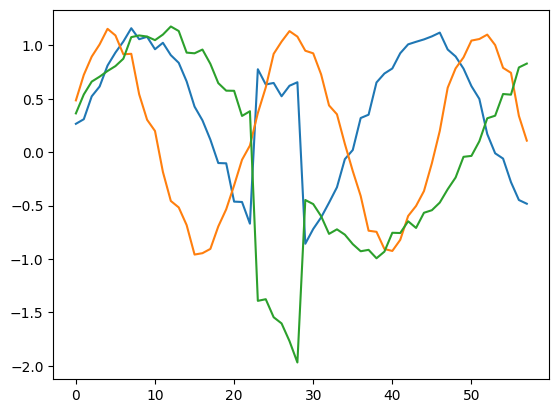

[False False False  True  True]


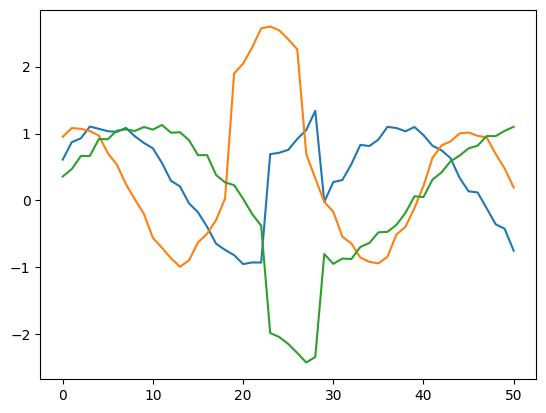

[False False False False False]


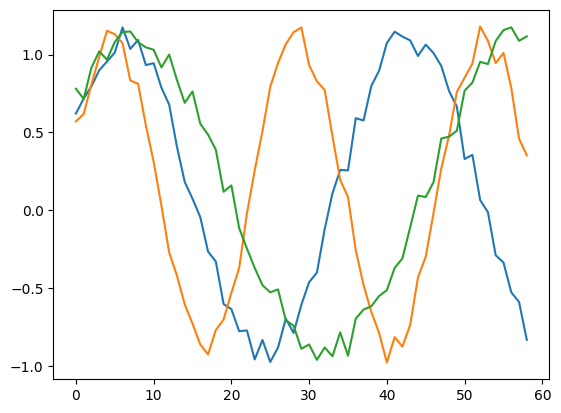

[ True False False False  True]


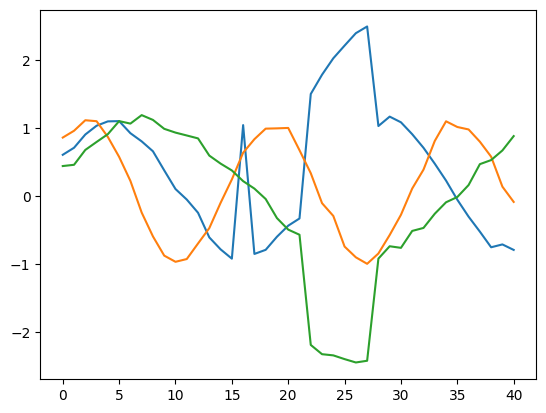

[False  True False False False]


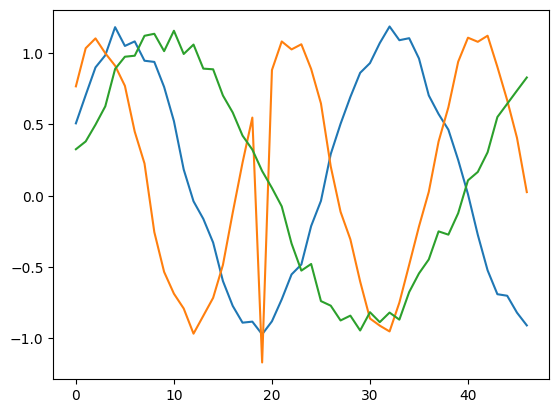

In [8]:
for i in range(5):
    plt.plot(xl[i])
    print(yl[i])
    plt.show()

In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Masking, Bidirectional, LSTM, Dense, Layer
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm



PADDING_VALUE = -10.0
max_len = max(len(x) for x in xl)
X = pad_sequences(xl, maxlen=max_len, padding='post', value=PADDING_VALUE, dtype='float32')
y = np.array(yl).astype('float32')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_mask = (X_train != PADDING_VALUE).any(axis=2)
test_mask = (X_test != PADDING_VALUE).any(axis=2)

scaler = StandardScaler()
scaler.fit(X_train[train_mask])

def scale_data(data, mask):
    data_scaled = data.copy()
    data_scaled[mask] = scaler.transform(data[mask])
    data_scaled[~mask] = PADDING_VALUE
    return data_scaled

X_train_scaled = scale_data(X_train, train_mask)
X_test_scaled = scale_data(X_test, test_mask)

2026-01-29 23:35:16.855880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 23:35:16.913077: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-29 23:35:18.220137: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/olek/sem5/myenv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.

In [10]:
# Attention Layer
class AttentionLayer(Layer):
    def __init__(self, **kwargs):
        self.supports_masking = True
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.W = self.add_weight(name="att_weight", shape=(input_shape[-1], 1),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_bias", shape=(1,),
                                 initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, x, mask=None):
        e = K.tanh(K.dot(x, self.W) + self.b)
        scores = K.squeeze(e, axis=-1)

        if mask is not None:
            mask = tf.cast(mask, tf.float32)
            scores = scores * mask - (1.0 - mask) * 1e9

        attention_weights = K.softmax(scores, axis=-1)
        context = K.sum(x * K.expand_dims(attention_weights, -1), axis=1)
        return context, attention_weights

    def compute_mask(self, inputs, mask=None):
        return [None, None]

    def compute_output_shape(self, input_shape):
        return [(input_shape[0], input_shape[-1]), (input_shape[0], input_shape[1])]

In [11]:
# Model Building
# Model optimization:
# Current LSTM setup yielded best results
# Both Convolution and Masking improve the classification results by a few percents.
# Standard Conv1D doesn't process masking. We tried implementing our own convolution with masking and changing the order of layers,
# but it didn't yield better results

# For future considerations:
# Increasing the size of convolution mask or adding pooling layers could improve saliency map results by helping model recognize bigger structures in data
inputs = Input(shape=(max_len, 3))
x = Conv1D(32, 3, padding='same', activation='relu')(inputs) # Conv1D doesn't process masking
x = Masking(mask_value=PADDING_VALUE)(x)
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Bidirectional(LSTM(32, return_sequences=True))(x)
context, attention_weights = AttentionLayer()(x)
outputs = Dense(5, activation='sigmoid')(context)

def weighted_binary_crossentropy(weights):
    def loss(y_true, y_pred):
        bce = K.binary_crossentropy(y_true, y_pred)
        weighted_bce = bce * weights
        return K.mean(weighted_bce)
    return loss

# We boost class 2 weight to improve its recognition
loss_weights = tf.constant([1.0, 1.0, 2.0, 1.0, 1.0])


model = Model(inputs, outputs)
attention_model = Model(inputs, attention_weights)
model.compile(
    optimizer='adam',
    loss=weighted_binary_crossentropy(loss_weights),
    metrics=['binary_accuracy']
)
model.summary()

2026-01-29 23:35:19.281473: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-01-29 23:35:19.281522: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:160] env: CUDA_VISIBLE_DEVICES="-1"
2026-01-29 23:35:19.281529: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:163] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-01-29 23:35:19.281534: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:171] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-01-29 23:35:19.281541: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:176] retrieving CUDA diagnostic information for host: olek-Precision-3560
2026-01-29 23:35:19.281544: I external/local_xla/xla/stream_executo

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 59, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 59, 32)    │        320 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 59, 32)    │          0 │ conv1d[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 59, 32)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 59)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 59, 128)   │     49,664 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 59, 64)    │     41,216 │ bidirectional[0]… │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_layer     │ [(None, 64),      │         65 │ bidirectional_1[… │
│ (AttentionLayer)    │ (None, 59)]       │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 5)         │        325 │ attention_layer[… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 91,590 (357.77 KB)

 Trainable params: 91,590 (357.77 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Training
history = model.fit(
    X_train_scaled, y_train,
    epochs=30, batch_size=64, validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6, verbose=1)
    ]
)

Epoch 1/30


2026-01-29 23:35:25.196695: E tensorflow/core/util/util.cc:131] oneDNN supports DT_BOOL only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


563/563 ━━━━━━━━━━━━━━━━━━━━ 34s 50ms/step - binary_accuracy: 0.8502 - loss: 0.4484 - val_binary_accuracy: 0.8759 - val_loss: 0.3905 - learning_rate: 0.0010
Epoch 2/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 29s 52ms/step - binary_accuracy: 0.9096 - loss: 0.3143 - val_binary_accuracy: 0.9408 - val_loss: 0.2386 - learning_rate: 0.0010
Epoch 3/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - binary_accuracy: 0.9504 - loss: 0.2021 - val_binary_accuracy: 0.9532 - val_loss: 0.1787 - learning_rate: 0.0010
Epoch 4/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 54ms/step - binary_accuracy: 0.9692 - loss: 0.1403 - val_binary_accuracy: 0.9656 - val_loss: 0.1514 - learning_rate: 0.0010
Epoch 5/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 30s 54ms/step - binary_accuracy: 0.9805 - loss: 0.0983 - val_binary_accuracy: 0.9681 - val_loss: 0.1419 - learning_rate: 0.0010
Epoch 6/30
563/563 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - binary_accuracy: 0.9855 - loss: 0.0786 - val_binary_accuracy: 0.9847 - val_loss: 0.0823 - learning_rate: 0.0010
Epo

In [13]:
# Evaluation
y_pred_probs = model.predict(X_test_scaled)
y_pred = (y_pred_probs > 0.4).astype(int)

print("\nClassification Report")
print(classification_report(y_test, y_pred, target_names=[f"Class {i}" for i in range(5)], zero_division=0))
print(f"Exact Match Accuracy: {accuracy_score(y_test, y_pred):.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step

Classification Report
              precision    recall  f1-score   support

     Class 0       1.00      1.00      1.00      2535
     Class 1       1.00      1.00      1.00      2484
     Class 2       0.99      0.98      0.98      2505
     Class 3       1.00      1.00      1.00      2566
     Class 4       1.00      1.00      1.00      2548

   micro avg       1.00      0.99      1.00     12638
   macro avg       1.00      0.99      1.00     12638
weighted avg       1.00      0.99      1.00     12638
 samples avg       0.77      0.77      0.77     12638

Exact Match Accuracy: 0.9907



Confusion Matrices (Per Class)


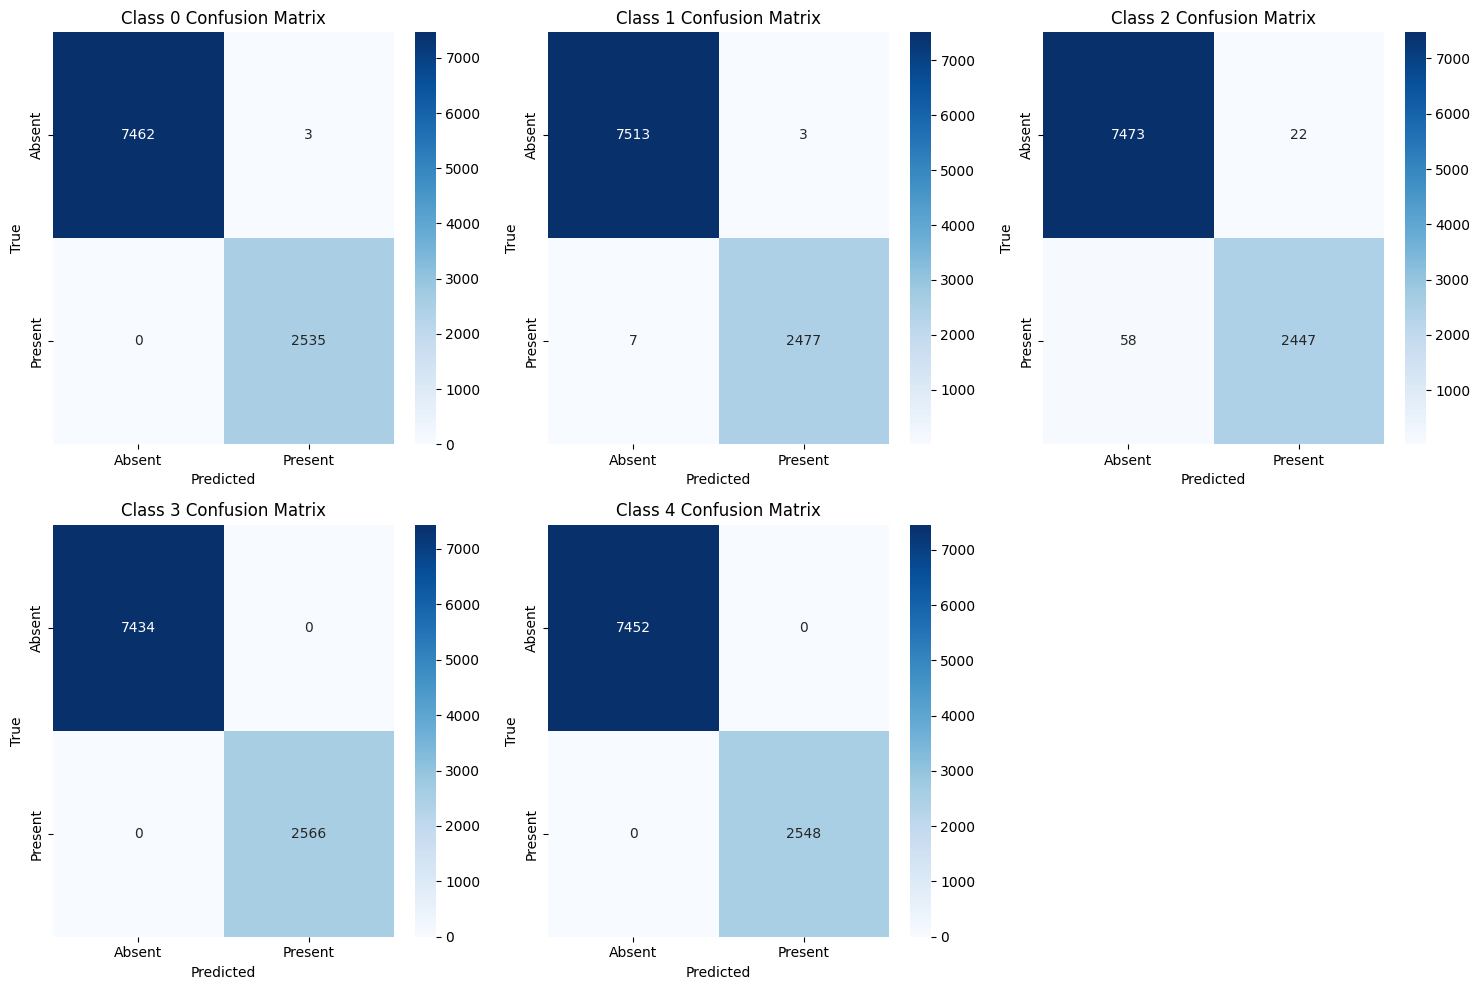


Multi-Label Pattern Analysis
Unique true label combinations: 32
Unique predicted label combinations: 32

Top 10 Most Common Prediction Patterns:
✓ True: [0,0,0,0,0] → Pred: [0,0,0,0,0] | 2313 (23.13%)
✓ True: [0,0,0,1,0] → Pred: [0,0,0,1,0] |  829 ( 8.29%)
✓ True: [0,1,0,0,0] → Pred: [0,1,0,0,0] |  820 ( 8.20%)
✓ True: [1,0,0,0,0] → Pred: [1,0,0,0,0] |  796 ( 7.96%)
✓ True: [0,0,1,0,0] → Pred: [0,0,1,0,0] |  751 ( 7.51%)
✓ True: [0,0,0,0,1] → Pred: [0,0,0,0,1] |  746 ( 7.46%)
✓ True: [0,0,1,0,1] → Pred: [0,0,1,0,1] |  295 ( 2.95%)
✓ True: [0,0,0,1,1] → Pred: [0,0,0,1,1] |  284 ( 2.84%)
✓ True: [1,0,0,1,0] → Pred: [1,0,0,1,0] |  279 ( 2.79%)
✓ True: [1,1,0,0,0] → Pred: [1,1,0,0,0] |  270 ( 2.70%)

Top 5 Most Common Misclassifications:
✗ True: [0,0,1,0,1] → Pred: [0,0,0,0,1] |   12 ( 0.12%)
✗ True: [0,0,1,1,1] → Pred: [0,0,0,1,1] |   11 ( 0.11%)
✗ True: [1,0,1,0,1] → Pred: [1,0,0,0,1] |   10 ( 0.10%)
✗ True: [0,0,0,0,1] → Pred: [0,0,1,0,1] |    7 ( 0.07%)
✗ True: [0,1,1,1,1] → Pred: [0,

In [14]:
# Confusion Matrices
print("\nConfusion Matrices (Per Class)")
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i in range(5):
    cm = confusion_matrix(y_test[:, i], y_pred[:, i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Absent', 'Present'], yticklabels=['Absent', 'Present'])
    axes[i].set_title(f'Class {i} Confusion Matrix')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('True')

axes[5].axis('off')
plt.tight_layout()
plt.show()

# Multi-Label Pattern Analysis
def format_pattern(pattern):
    return '[' + ','.join(str(int(x)) for x in pattern) + ']'

print("\nMulti-Label Pattern Analysis")
y_test_tuples = [tuple(int(x) for x in row) for row in y_test]
y_pred_tuples = [tuple(int(x) for x in row) for row in y_pred]

unique_true = set(y_test_tuples)
unique_pred = set(y_pred_tuples)

print(f"Unique true label combinations: {len(unique_true)}")
print(f"Unique predicted label combinations: {len(unique_pred)}")

pattern_confusion = {}
for true_pattern, pred_pattern in zip(y_test_tuples, y_pred_tuples):
    key = (true_pattern, pred_pattern)
    pattern_confusion[key] = pattern_confusion.get(key, 0) + 1

print("\nTop 10 Most Common Prediction Patterns:")
sorted_patterns = sorted(pattern_confusion.items(), key=lambda x: x[1], reverse=True)
for (true_pat, pred_pat), count in sorted_patterns[:10]:
    match = "✓" if true_pat == pred_pat else "✗"
    pct = 100 * count / len(y_test)
    print(f"{match} True: {format_pattern(true_pat)} → Pred: {format_pattern(pred_pat)} | {count:4d} ({pct:5.2f}%)")

misclassified_patterns = [(t, p, c) for (t, p), c in sorted_patterns if t != p]
if misclassified_patterns:
    print("\nTop 5 Most Common Misclassifications:")
    for true_pat, pred_pat, count in misclassified_patterns[:5]:
        pct = 100 * count / len(y_test)
        print(f"✗ True: {format_pattern(true_pat)} → Pred: {format_pattern(pred_pat)} | {count:4d} ({pct:5.2f}%)")

In [15]:
# Consolidated Class 2 Error Analysis (False Positives & False Negatives)
def analyze_class_errors(class_idx, y_true, y_pred, max_patterns=5):

    print(f"CLASS {class_idx} ERROR ANALYSIS")

    # False Positives
    false_pos_mask = (y_true[:, class_idx] == 0) & (y_pred[:, class_idx] == 1)
    false_pos_indices = np.where(false_pos_mask)[0]

    # False Negatives
    false_neg_mask = (y_true[:, class_idx] == 1) & (y_pred[:, class_idx] == 0)
    false_neg_indices = np.where(false_neg_mask)[0]

    print(f"\nTotal False Positives: {len(false_pos_indices)}")
    print(f"Total False Negatives: {len(false_neg_indices)}")

    # Analyze both error types
    for error_type, indices, title in [
        ("FALSE POSITIVES", false_pos_indices, "when we falsely predicted Class"),
        ("FALSE NEGATIVES", false_neg_indices, "when we failed to predict Class")
    ]:
        if len(indices) == 0:
            print(f"\n{error_type}: None found!")
            continue

        print(f"\n{'-'*60}")
        print(f"{error_type} ({len(indices)} cases)")
        print(f"{'-'*60}")

        true_labels = y_true[indices]
        num_classes_per_sample = true_labels.sum(axis=1)
        class_count_distribution = Counter(num_classes_per_sample.astype(int))

        print(f"\nDistribution of number of TRUE classes present ({title} {class_idx}):")
        for num_classes in sorted(class_count_distribution.keys()):
            count = class_count_distribution[num_classes]
            pct = 100 * count / len(indices)
            print(f"  {num_classes} classes: {count:4d} ({pct:5.2f}%)")

        print(f"\nWhich {'OTHER ' if error_type == 'FALSE NEGATIVES' else ''}classes were present:")
        for other_class_idx in range(5):
            if other_class_idx == class_idx and error_type == "FALSE NEGATIVES":
                continue  # Skip the class itself for FN (it's always present)
            if other_class_idx == class_idx and error_type == "FALSE POSITIVES":
                continue  # Skip the class itself for FP (it's never present)

            count = int(true_labels[:, other_class_idx].sum())
            pct = 100 * count / len(indices)

            note = ""
            # Add contextual notes for relevant class interactions
            if class_idx == 2 and other_class_idx == 4:
                note = " <- (modifies same sin wave as class 2)"

            print(f"  Class {other_class_idx}: {count:4d} ({pct:5.2f}%){note}")

        print(f"\nMost common TRUE label patterns:")
        patterns = [tuple(int(x) for x in row) for row in true_labels]
        pattern_counts = Counter(patterns)
        for pattern, count in pattern_counts.most_common(max_patterns):
            pct = 100 * count / len(indices)
            print(f"  {format_pattern(pattern)}: {count:4d} ({pct:5.2f}%)")

# Run the analysis for Class 2
analyze_class_errors(2, y_test, y_pred, max_patterns=10)

CLASS 2 ERROR ANALYSIS

Total False Positives: 22
Total False Negatives: 58

------------------------------------------------------------
FALSE POSITIVES (22 cases)
------------------------------------------------------------

Distribution of number of TRUE classes present (when we falsely predicted Class 2):
  0 classes:    1 ( 4.55%)
  1 classes:    8 (36.36%)
  2 classes:   10 (45.45%)
  3 classes:    3 (13.64%)

Which classes were present:
  Class 0:    6 (27.27%)
  Class 1:    5 (22.73%)
  Class 3:    9 (40.91%)
  Class 4:   17 (77.27%) <- (modifies same sin wave as class 2)

Most common TRUE label patterns:
  [0,0,0,0,1]:    7 (31.82%)
  [0,0,0,1,1]:    3 (13.64%)
  [1,0,0,0,1]:    3 (13.64%)
  [0,1,0,1,0]:    2 ( 9.09%)
  [0,0,0,0,0]:    1 ( 4.55%)
  [0,1,0,1,1]:    1 ( 4.55%)
  [1,0,0,1,0]:    1 ( 4.55%)
  [0,0,0,1,0]:    1 ( 4.55%)
  [0,1,0,0,1]:    1 ( 4.55%)
  [1,1,0,0,1]:    1 ( 4.55%)

------------------------------------------------------------
FALSE NEGATIVES (58 cases)


**False negative or positive for class 2 almost always when other classes are also present**

In [16]:
def get_saliency(sample_idx, class_idx=None, target_neutral=False):
    sample = tf.convert_to_tensor(X_test_scaled[sample_idx:sample_idx+1], dtype=tf.float32)

    if target_neutral:
        # Compute gradient to push ALL predictions toward 0 (neutral/no defect)
        with tf.GradientTape() as tape:
            tape.watch(sample)
            pred = model(sample)
            # Loss: sum of all predictions (we want to minimize this to reach neutral)
            # Negative because gradient points in direction of increase
            loss = -tf.reduce_sum(pred)

        grads = tape.gradient(loss, sample).numpy()[0]
        # Gradient shows direction to DECREASE predictions (toward neutral)
        saliency = np.abs(grads)
    else:
        # Original behavior: gradient for specific class
        if class_idx is None:
            class_idx = 2
        with tf.GradientTape() as tape:
            tape.watch(sample)
            pred = model(sample)
            score = pred[0, class_idx]
        grads = tape.gradient(score, sample).numpy()[0]
        saliency = np.abs(grads)

    # Normalize
    return (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)


def visualize_root_cause(sample_idx, classes_of_interest, saliency_class=None, show_neutral_path=True):
    if not isinstance(classes_of_interest, (list, np.ndarray)):
        classes_of_interest = [classes_of_interest]

    # Determine which class to use for saliency
    if saliency_class is None:
        saliency_class = classes_of_interest[0] if len(classes_of_interest) > 0 else 2

    attention = attention_model.predict(X_test_scaled[sample_idx:sample_idx+1], verbose=0)[0]

    if show_neutral_path:
        saliency = get_saliency(sample_idx, target_neutral=True)
    else:
        saliency = get_saliency(sample_idx, saliency_class)

    sample_original = X_test[sample_idx]
    actual_len_idx = np.where(sample_original[:, 0] == PADDING_VALUE)[0]
    actual_len = actual_len_idx[0] if len(actual_len_idx) > 0 else max_len

    full_data = np.zeros((max_len, 3))
    full_attention = np.zeros(max_len)
    full_saliency = np.zeros((max_len, 3))

    full_data[:actual_len] = sample_original[:actual_len]
    full_attention[:actual_len] = attention[:actual_len]
    full_saliency[:actual_len] = saliency[:actual_len]

    time_steps = np.arange(max_len)

    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                            gridspec_kw={'height_ratios': [3, 1, 2]})

    for i, label in enumerate(['Sensor 0', 'Sensor 1', 'Sensor 2']):
        axes[0].plot(time_steps, full_data[:, i], label=label, linewidth=1.5)
    axes[0].axvline(x=actual_len, color='red', linestyle='--', alpha=0.5, label='Data End')
    axes[0].legend(loc='upper right')
    axes[0].set_ylabel("Signal Value")

    # Build title based on classes present
    if len(classes_of_interest) == 0:
        title = f"Sample {sample_idx} | No Defect"
    else:
        class_str = ', '.join([f"Class {c}" for c in classes_of_interest])
        title = f"Sample {sample_idx} | {class_str}"

    axes[0].set_title(title)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, max_len-1])

    axes[1].fill_between(time_steps, full_attention, color='orange', alpha=0.6)
    axes[1].axvline(x=actual_len, color='red', linestyle='--', alpha=0.5)
    axes[1].set_ylabel("Attention\nWeight")
    axes[1].set_title("Temporal Focus (When?)")
    axes[1].set_ylim([0, full_attention.max() * 1.1 if full_attention.max() > 0 else 0.1])
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim([0, max_len-1])

    axes[2].imshow(full_saliency.T, aspect='auto', cmap="inferno",
                   interpolation='nearest', extent=[0, max_len-1, -0.5, 2.5])
    axes[2].axvline(x=actual_len, color='red', linestyle='--', alpha=0.5)
    axes[2].set_ylabel("Sensor")
    axes[2].set_yticks([0, 1, 2])
    axes[2].set_yticklabels(['S0', 'S1', 'S2'])
    axes[2].set_xlabel("Time Step")

    if show_neutral_path:
        axes[2].set_title("What to Change to Reach Neutral (No Defects)")
    else:
        axes[2].set_title(f"Sensor Focus (Which?) - Gradient for Class {saliency_class}")

    axes[2].set_xlim([0, max_len-1])

    plt.tight_layout()
    plt.show()

Here we present our first approach for model explainability. The worse of the 2 - saliency maps + attention


✓ NO DEFECT | Sample 1
   True: [0,0,0,0,0] | Pred: [0,0,0,0,0]


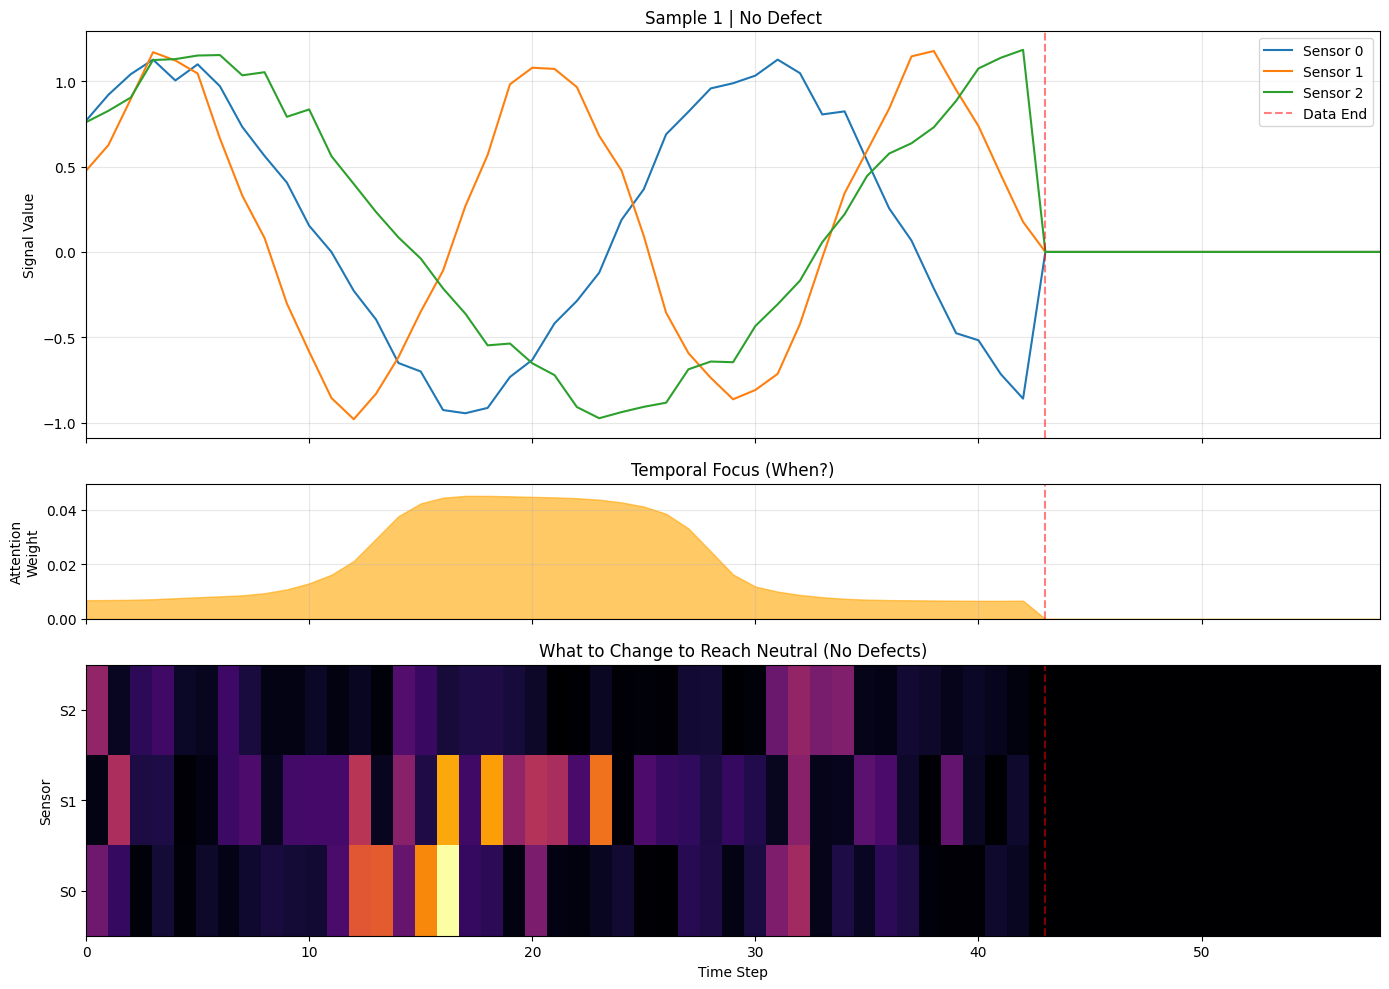


SINGLE DEFECT EXAMPLES

✓ CLASS 0 ONLY | Sample 29
   True: [1,0,0,0,0] | Pred: [1,0,0,0,0]


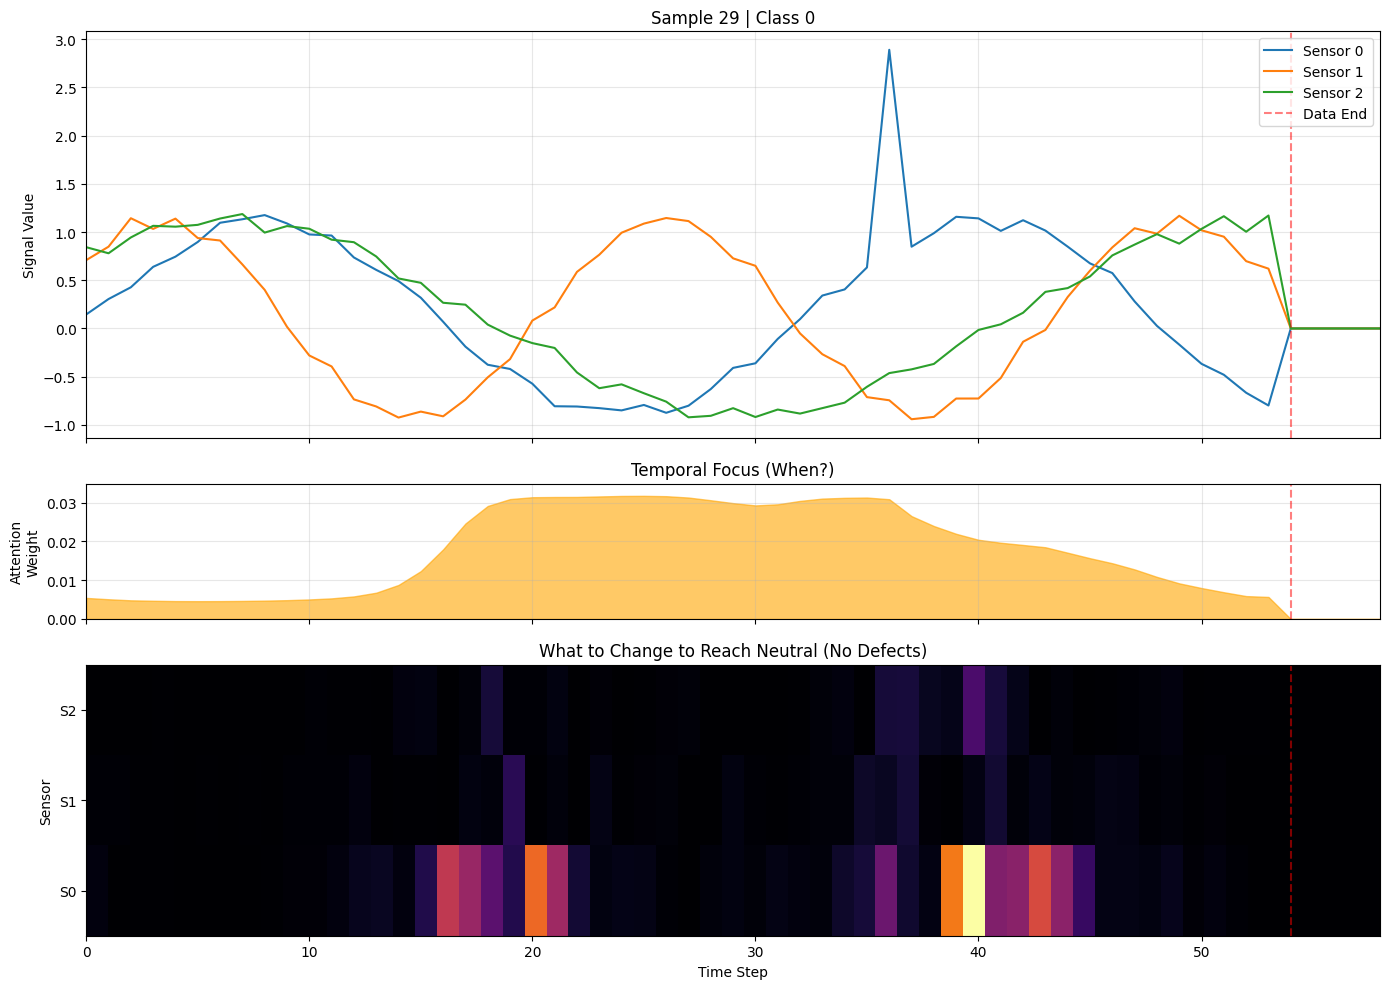


✓ CLASS 1 ONLY | Sample 11
   True: [0,1,0,0,0] | Pred: [0,1,0,0,0]


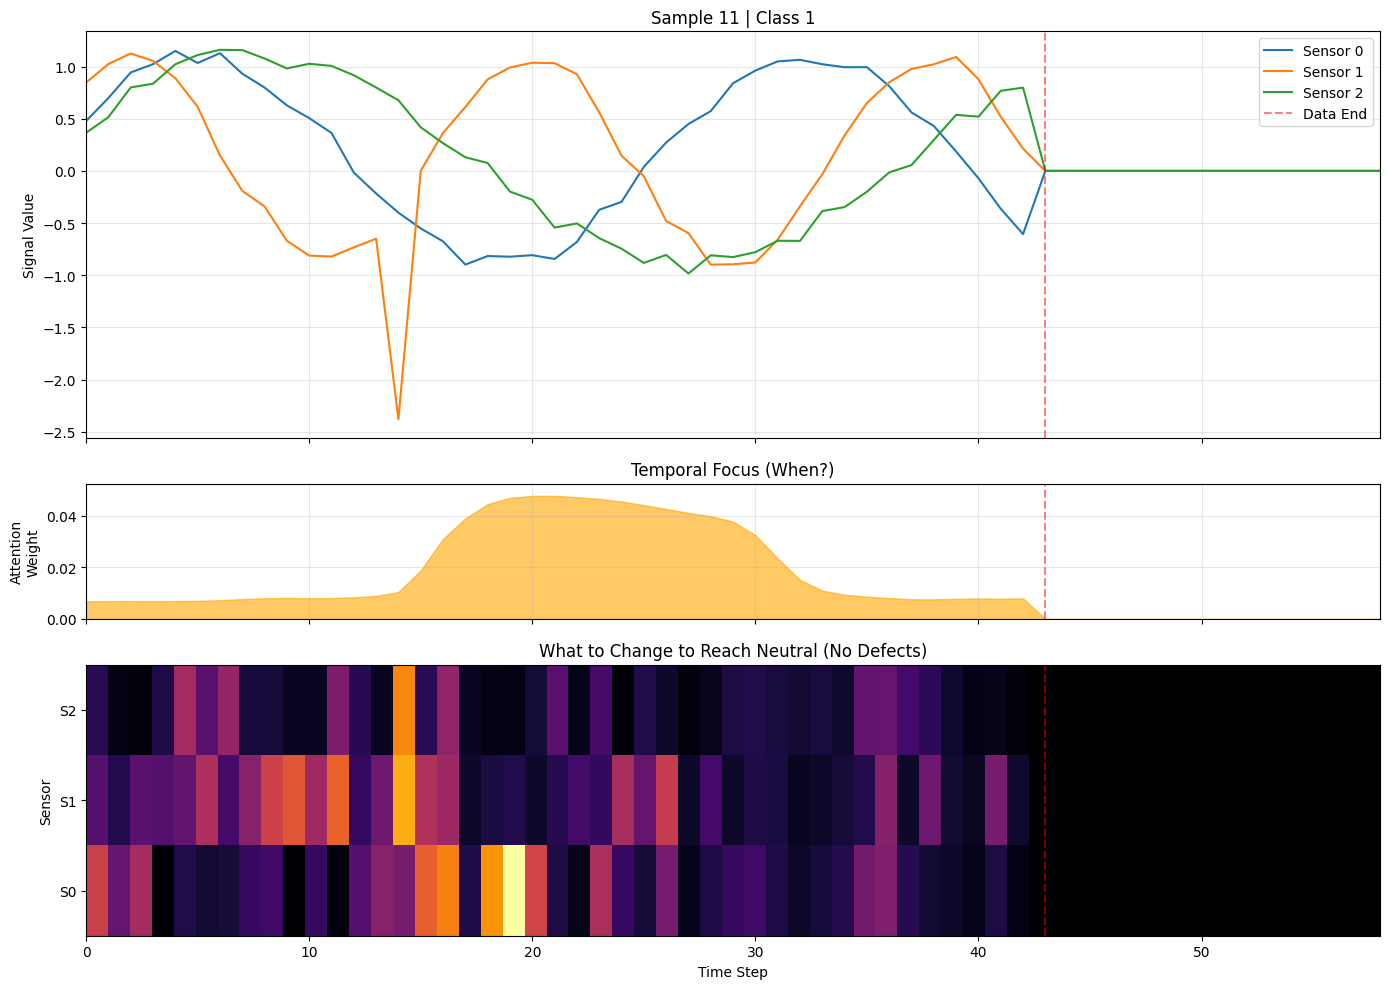


✓ CLASS 2 ONLY | Sample 0
   True: [0,0,1,0,0] | Pred: [0,0,1,0,0]


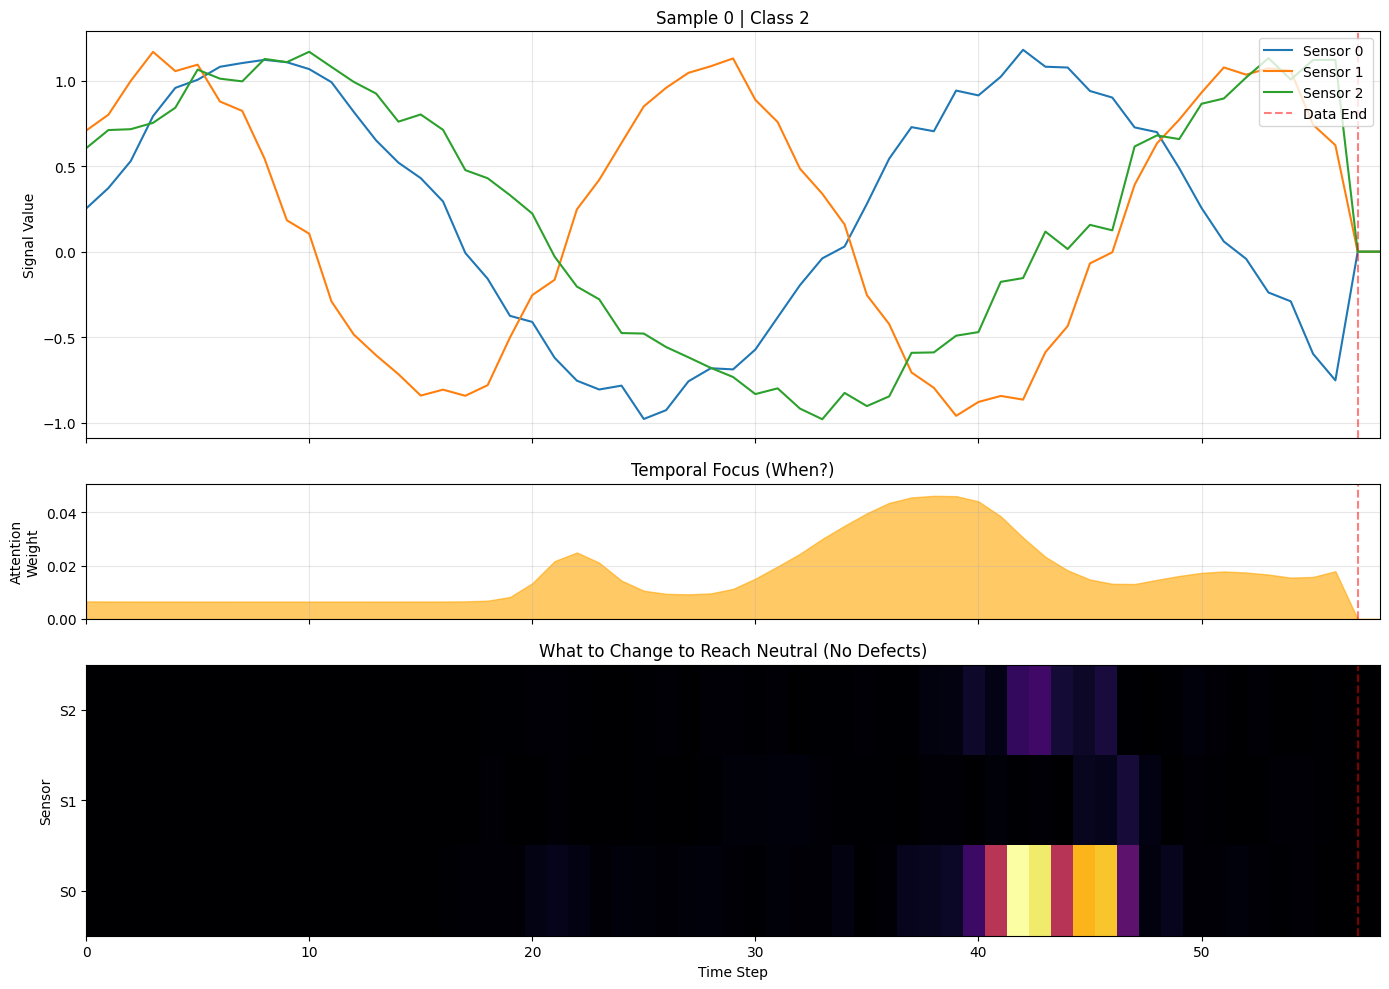


✓ CLASS 3 ONLY | Sample 19
   True: [0,0,0,1,0] | Pred: [0,0,0,1,0]


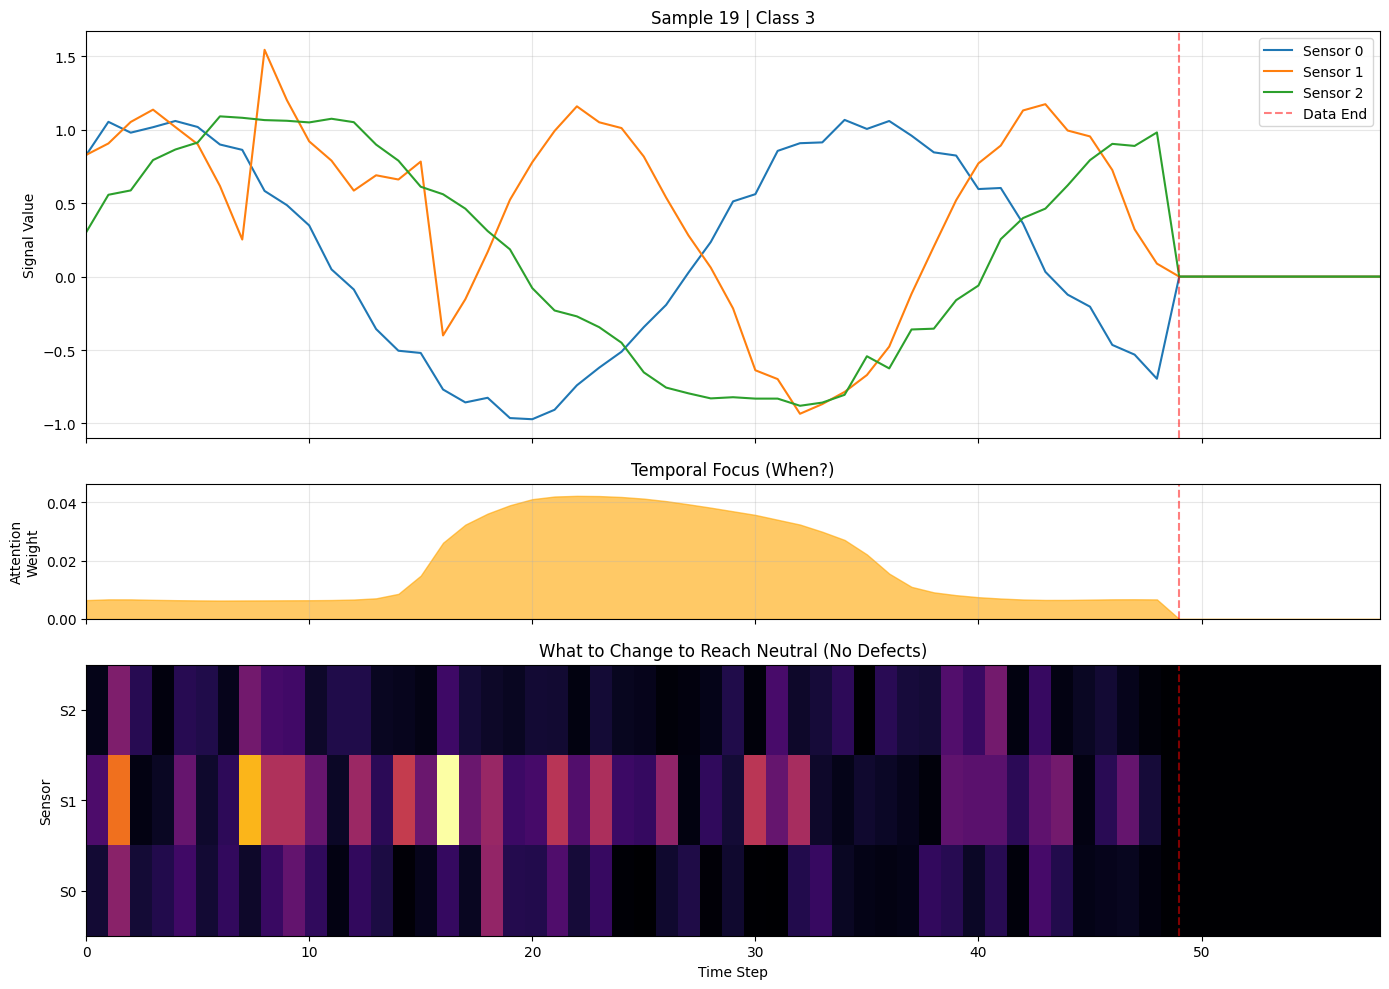


✓ CLASS 4 ONLY | Sample 41
   True: [0,0,0,0,1] | Pred: [0,0,0,0,1]


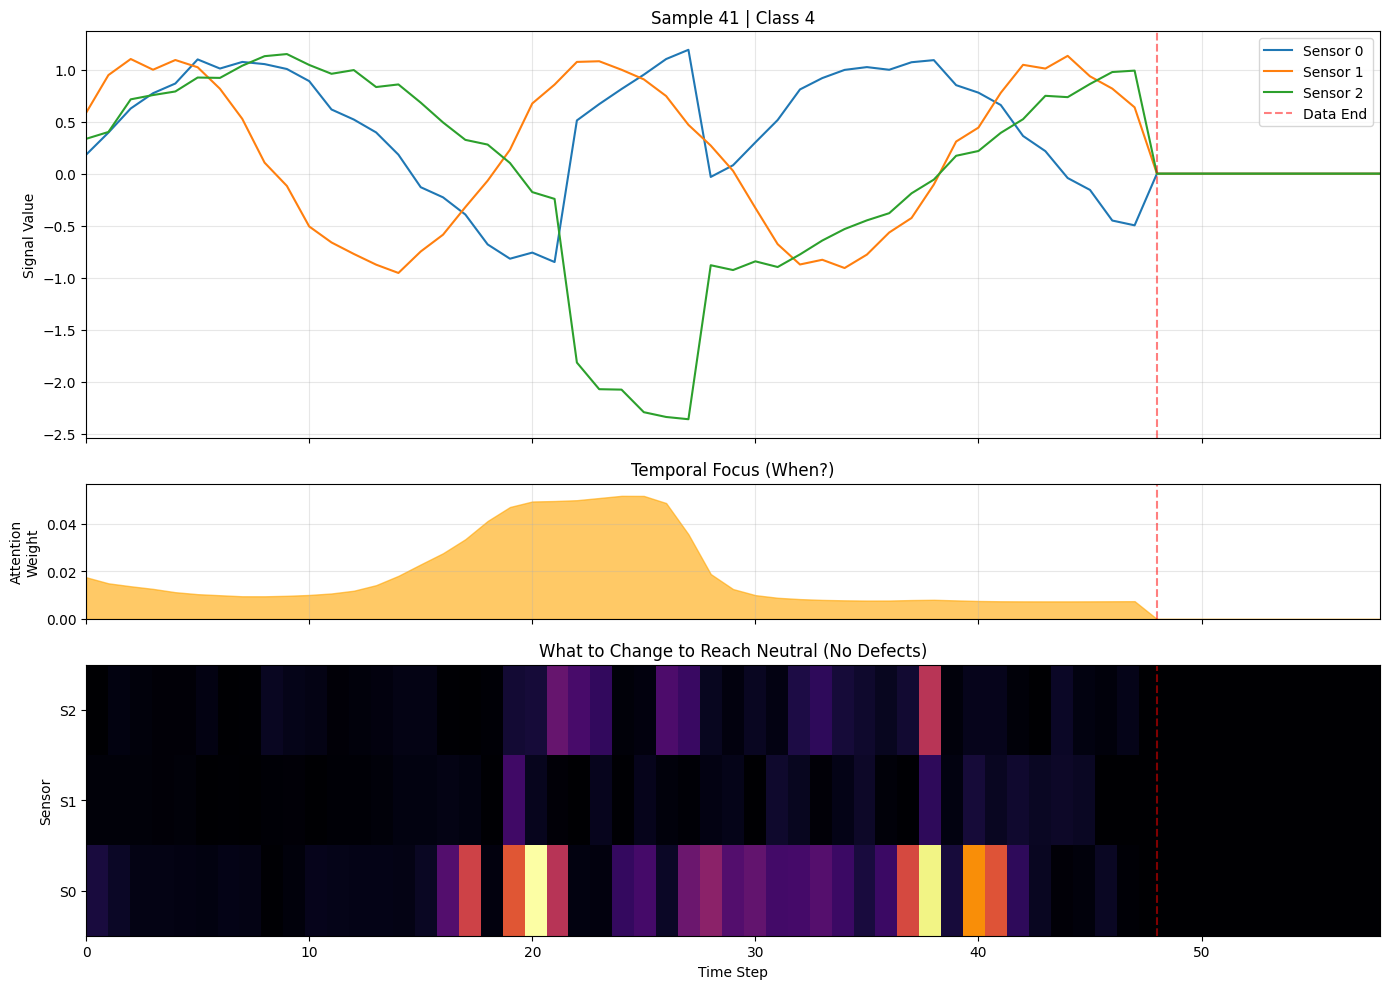

In [17]:
no_defect_idx = np.where((y_test.sum(axis=1) == 0))[0]
if len(no_defect_idx) > 0:
    idx = no_defect_idx[0]
    match = "✓" if np.array_equal(y_test[idx], y_pred[idx]) else "✗"
    print(f"\n{match} NO DEFECT | Sample {idx}")
    print(f"   True: {format_pattern(y_test[idx])} | Pred: {format_pattern(y_pred[idx])}")
    visualize_root_cause(idx, classes_of_interest=[], saliency_class=2)

print("\nSINGLE DEFECT EXAMPLES")
for class_idx in range(5):
    single_class_idx = np.where((y_test[:, class_idx] == 1) & (y_test.sum(axis=1) == 1))[0]
    if len(single_class_idx) > 0:
        idx = single_class_idx[0]
        match = "✓" if np.array_equal(y_test[idx], y_pred[idx]) else "✗"
        print(f"\n{match} CLASS {class_idx} ONLY | Sample {idx}")
        print(f"   True: {format_pattern(y_test[idx])} | Pred: {format_pattern(y_pred[idx])}")
        visualize_root_cause(idx, classes_of_interest=[class_idx], saliency_class=class_idx)

Here Saliency Map shows which points in the input most influence the model's prediction. Saliency map computes gradients, so it tells us how much the model's prediction would change if we change the value of that particular point only slightly. So it doesn't necessarily tell us which point is responsible for a defect, but tells us which points most influence the model's prediction even if we change their value only a little bit.


MOST COMMON MISCLASSIFICATION PATTERNS

✗ MISCLASSIFICATION #1 Example 1/1 | Sample 611 | Pattern occurs 12 times (0.12%)
   True: [0,0,1,0,1] | Pred: [0,0,0,0,1]


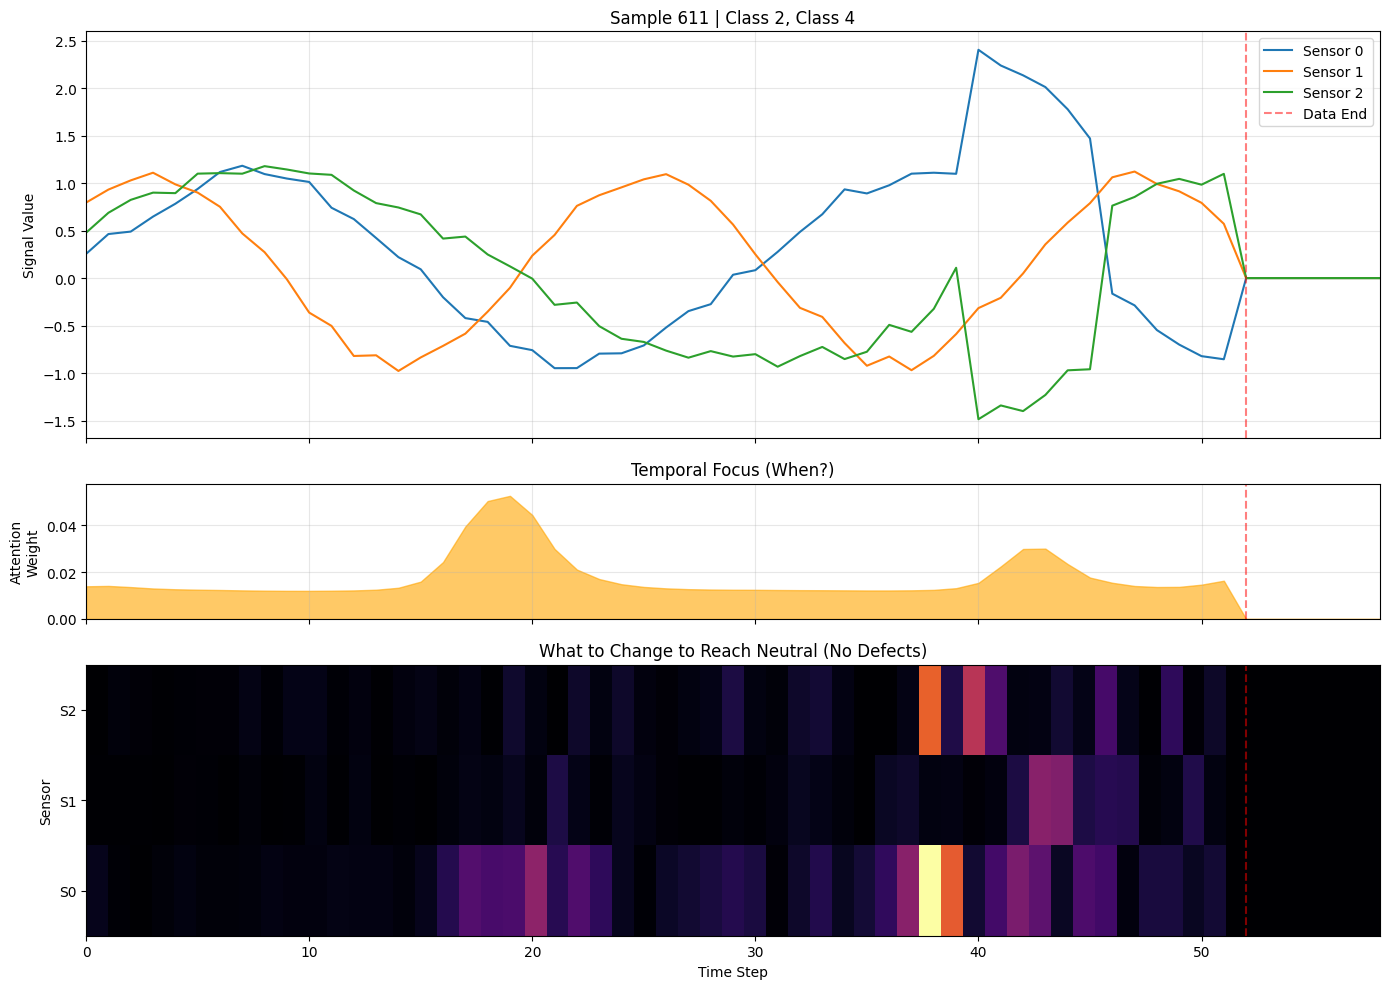


✗ MISCLASSIFICATION #2 Example 1/1 | Sample 793 | Pattern occurs 11 times (0.11%)
   True: [0,0,1,1,1] | Pred: [0,0,0,1,1]


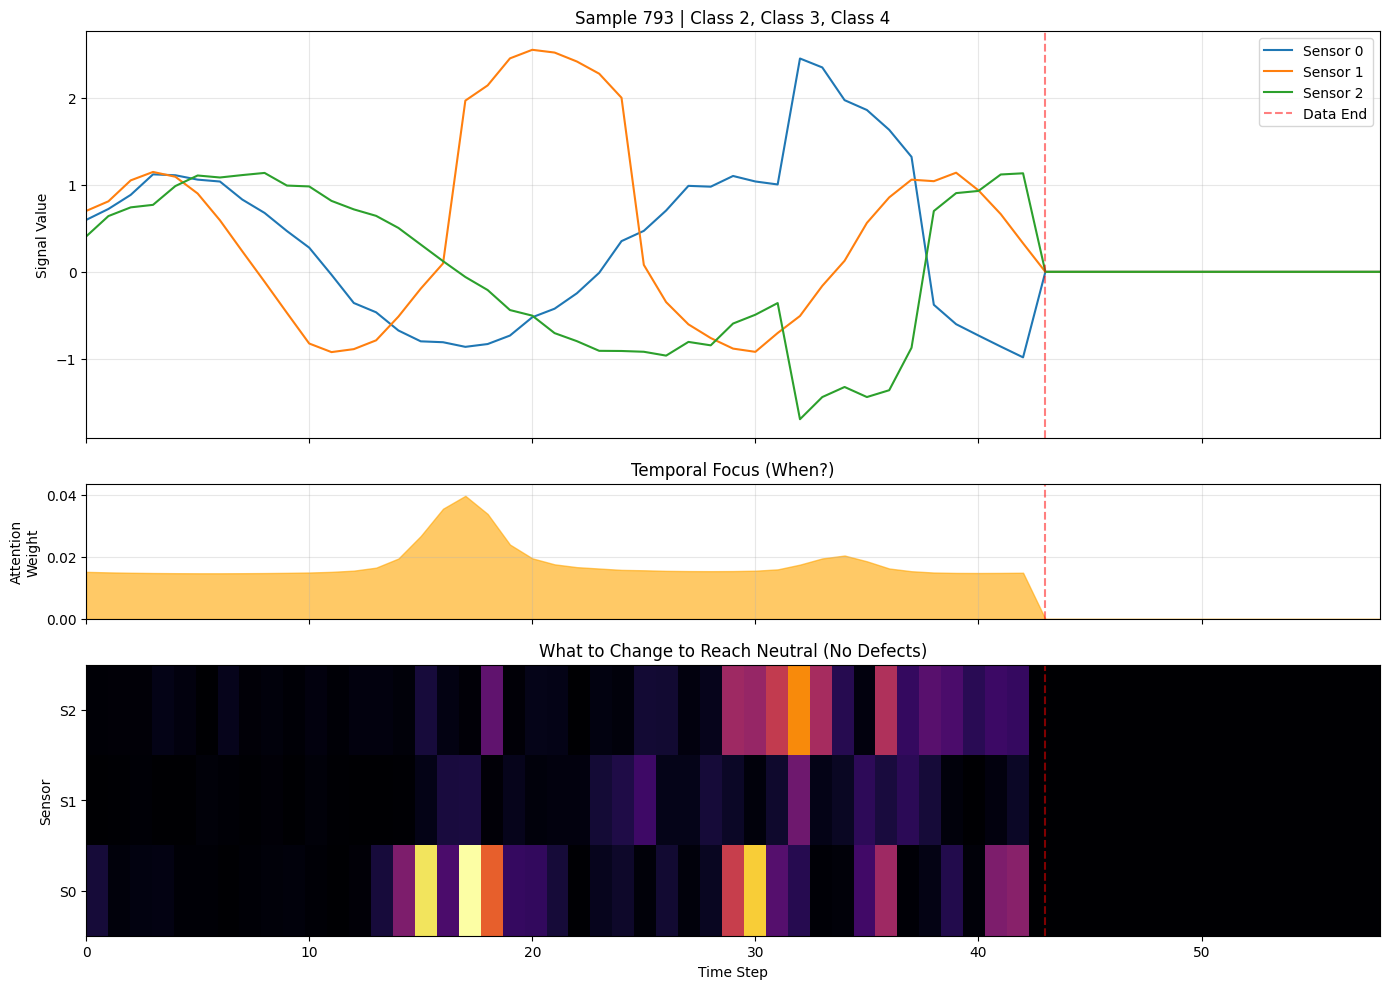


✗ MISCLASSIFICATION #3 Example 1/1 | Sample 1790 | Pattern occurs 10 times (0.10%)
   True: [1,0,1,0,1] | Pred: [1,0,0,0,1]


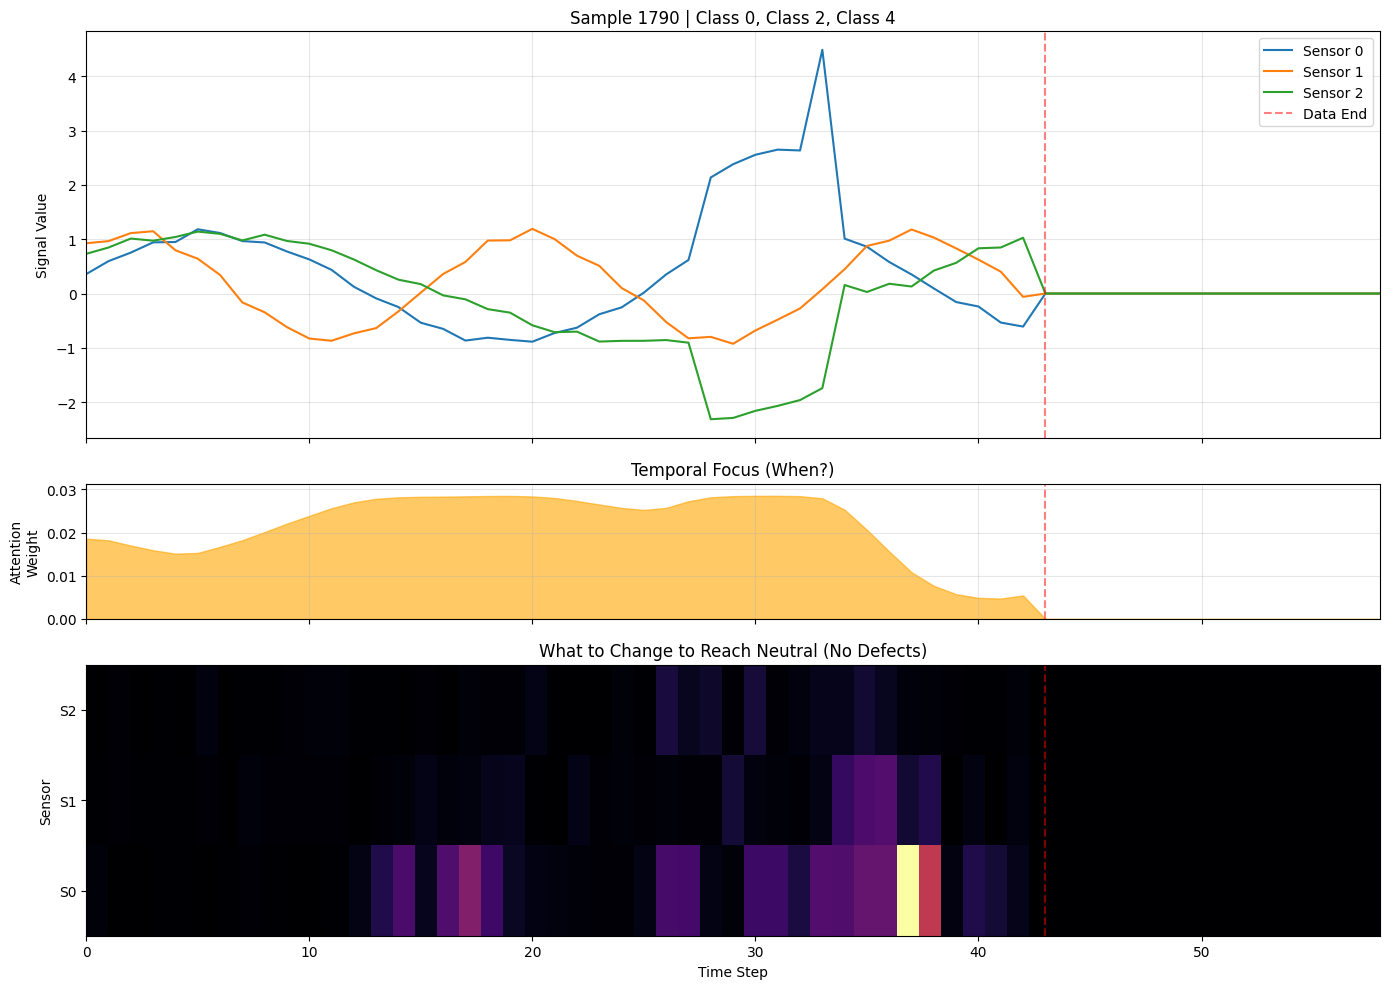

In [18]:
if len(misclassified_patterns) > 0:
    print("\nMOST COMMON MISCLASSIFICATION PATTERNS")

    for pattern_idx, (true_pat, pred_pat, count) in enumerate(misclassified_patterns[:3]):
        matching_samples = [i for i, (t, p) in enumerate(zip(y_test_tuples, y_pred_tuples))
                           if t == true_pat and p == pred_pat]

        if matching_samples:
            # Show 1 example of each pattern
            examples_to_show = min(1, len(matching_samples))

            for example_num in range(examples_to_show):
                idx = matching_samples[example_num]
                pct = 100 * count / len(y_test)

                print(f"\n✗ MISCLASSIFICATION #{pattern_idx+1} Example {example_num+1}/{examples_to_show} | Sample {idx} | "
                      f"Pattern occurs {count} times ({pct:.2f}%)")
                print(f"   True: {format_pattern(true_pat)} | Pred: {format_pattern(pred_pat)}")

                # Get all classes that are present in true labels
                classes_present = [i for i in range(5) if y_test[idx][i] == 1]
                visualize_root_cause(idx, classes_of_interest=classes_present, saliency_class=2)

Here is our 2nd better approach for model explainability

In [19]:
def optimal_value_analysis(model, sample_scaled, sample_original, class_idx,
                           actual_len, step_size=0.1, max_steps=50):

    max_len, num_sensors = sample_scaled.shape[1], sample_scaled.shape[2]

    # Get baseline prediction
    baseline_pred = model.predict(sample_scaled, verbose=0)[0, class_idx]

    # Compute global min/max thresholds across ALL sensors in the actual data portion
    all_values = sample_scaled[0, :actual_len, :].flatten()
    global_min = np.min(all_values)
    global_max = np.max(all_values)

    print(f"  Global value range: [{global_min:.3f}, {global_max:.3f}]")

    # Initialize maps
    optimal_map = np.zeros((max_len, num_sensors))
    current_map = np.zeros((max_len, num_sensors))
    correction_map = np.zeros((max_len, num_sensors))
    min_predictions = np.zeros((max_len, num_sensors))
    prediction_reduction = np.zeros((max_len, num_sensors))

    # For each time point and sensor
    for t in range(actual_len):
        for sensor_idx in range(num_sensors):
            current_value = sample_scaled[0, t, sensor_idx]
            current_map[t, sensor_idx] = current_value

            # Get prediction with current value
            pred_current = model.predict(sample_scaled, verbose=0)[0, class_idx]

            # Try stepping UP
            best_value_up = current_value
            best_pred_up = pred_current

            test_value = current_value
            prev_pred = pred_current

            for step in range(max_steps):
                test_value += step_size

                # Check if we've exceeded threshold
                if test_value > global_max:
                    break

                # Test this value
                sample_test = sample_scaled.copy()
                sample_test[0, t, sensor_idx] = test_value
                pred = model.predict(sample_test, verbose=0)[0, class_idx]

                # If prediction improved (decreased), continue
                if pred < prev_pred:
                    best_value_up = test_value
                    best_pred_up = pred
                    prev_pred = pred
                else:
                    # Prediction stopped improving, stop stepping up
                    break

            # Try stepping DOWN
            best_value_down = current_value
            best_pred_down = pred_current

            test_value = current_value
            prev_pred = pred_current

            for step in range(max_steps):
                test_value -= step_size

                # Check if we've exceeded threshold
                if test_value < global_min:
                    break

                # Test this value
                sample_test = sample_scaled.copy()
                sample_test[0, t, sensor_idx] = test_value
                pred = model.predict(sample_test, verbose=0)[0, class_idx]

                # If prediction improved (decreased), continue
                if pred < prev_pred:
                    best_value_down = test_value
                    best_pred_down = pred
                    prev_pred = pred
                else:
                    # Prediction stopped improving, stop stepping down
                    break

            # Choose the direction that gave the best result
            if best_pred_up < best_pred_down:
                optimal_value = best_value_up
                min_pred = best_pred_up
            else:
                optimal_value = best_value_down
                min_pred = best_pred_down

            optimal_map[t, sensor_idx] = optimal_value
            min_predictions[t, sensor_idx] = min_pred
            correction_map[t, sensor_idx] = optimal_value - current_value

            # How much does prediction decrease if we use optimal value?
            prediction_reduction[t, sensor_idx] = pred_current - min_pred

    return optimal_map, current_map, correction_map, min_predictions, prediction_reduction, baseline_pred


def visualize_optimal_value_analysis(sample_idx, X_test, X_test_scaled, model,
                                     max_len, PADDING_VALUE,
                                     classes_to_analyze=None,
                                     step_size=0.1,
                                     max_steps=50):

    sample_scaled = X_test_scaled[sample_idx:sample_idx+1]
    sample_original = X_test[sample_idx]

    actual_len_idx = np.where(sample_original[:, 0] == PADDING_VALUE)[0]
    actual_len = actual_len_idx[0] if len(actual_len_idx) > 0 else max_len

    # Get prediction to determine which classes to analyze
    prediction = model.predict(sample_scaled, verbose=0)[0]

    if classes_to_analyze is None:
        detected_classes = np.where(prediction > 0.5)[0].tolist()
        if len(detected_classes) == 0:
            classes_to_analyze = [2]
            print(f"No class with prediction > 0.5, using default class 2")
        else:
            classes_to_analyze = detected_classes
            print(f"Detected classes (pred > 0.5): {classes_to_analyze}")
    elif not isinstance(classes_to_analyze, list):
        classes_to_analyze = [classes_to_analyze]

    num_classes = len(classes_to_analyze)

    print(f"Running optimal value analysis for {num_classes} class(es): {classes_to_analyze}")
    print(f"Step size: {step_size}, Max steps: {max_steps}")

    results = []
    for class_idx in classes_to_analyze:
        optimal_map, current_map, correction_map, min_preds, pred_reduction, baseline_pred = optimal_value_analysis(
            model, sample_scaled, sample_original, class_idx,
            actual_len, step_size, max_steps
        )
        results.append({
            'optimal': optimal_map,
            'current': current_map,
            'correction': correction_map,
            'min_preds': min_preds,
            'pred_reduction': pred_reduction,
            'baseline': baseline_pred
        })

    # Prepare data for plotting
    time_steps = np.arange(max_len)
    full_data = np.zeros((max_len, 3))
    full_data[:actual_len] = sample_original[:actual_len]

    # Create figure: sensor graph + (importance + optimal values) for each class
    # height_ratios: 3 for sensor graph, then 3,3 for each class pair
    height_ratios = [3] + [3, 3] * num_classes
    fig, axes = plt.subplots(1 + 2 * num_classes, 1,
                            figsize=(16, 4 + 6 * num_classes),
                            sharex=True, squeeze=False,
                            gridspec_kw={'height_ratios': height_ratios})
    axes = axes.flatten()

    # Plot original sensor data
    for i, label in enumerate(['Sensor 0', 'Sensor 1', 'Sensor 2']):
        axes[0].plot(time_steps, full_data[:, i], label=label, linewidth=1.5, alpha=0.8)
    axes[0].axvline(x=actual_len, color='red', linestyle='--', alpha=0.7, linewidth=2, label='Data End')
    axes[0].legend(loc='upper right')
    axes[0].set_ylabel("Signal Value", fontsize=11, fontweight='bold')

    detected_classes = np.where(prediction > 0.5)[0]
    if len(detected_classes) > 0:
        detected_str = ', '.join([f"C{i}: {prediction[i]:.3f}" for i in detected_classes])
        title_sensor = f"Sample {sample_idx} - Original Sensor Readings | Detected Defects: {detected_str}"
    else:
        title_sensor = f"Sample {sample_idx} - Original Sensor Readings | No Defects Detected (all predictions < 0.5)"

    axes[0].set_title(title_sensor, fontsize=11, fontweight='bold', loc='left')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim([0, max_len-1])

    # Plot importance and optimal maps for each class
    for idx, class_idx in enumerate(classes_to_analyze):
        result = results[idx]
        ax_importance = axes[1 + idx * 2]  # Offset by 1 (just sensor graph)
        ax_optimal = axes[1 + idx * 2 + 1]

        # Prepare full arrays - use prediction reduction as importance map
        full_importance = np.zeros((max_len, 3))
        full_importance[:actual_len] = result['pred_reduction'][:actual_len]

        full_correction = np.zeros((max_len, 3))
        full_correction[:actual_len] = result['correction'][:actual_len]


        # Shows how much prediction decreases if we fix this point

        # Use sequential colormap - higher = more important
        im_imp = ax_importance.imshow(full_importance.T, aspect='auto', cmap="hot",
                                      interpolation='nearest',
                                      extent=[0, max_len-1, -0.5, 2.5],
                                      vmin=0, vmax=1.0)

        ax_importance.axvline(x=actual_len, color='cyan', linestyle='--',
                             alpha=0.7, linewidth=2, label='Data End')
        ax_importance.set_ylabel("Sensor", fontsize=11, fontweight='bold')
        ax_importance.set_yticks([0, 1, 2])
        ax_importance.set_yticklabels(['S2', 'S1', 'S0'])
        ax_importance.legend(loc='upper right')

        cbar_imp = plt.colorbar(im_imp, ax=ax_importance,
                                orientation='horizontal', pad=0.15, aspect=30)
        cbar_imp.set_label('Defect Importance (Prediction Reduction)', fontsize=10)

        baseline = result['baseline']

        title_imp = (f"C{class_idx} - DEFECT IMPORTANCE MAP (Pred: {baseline:.4f})\n"
                     f"How much prediction DECREASES if we fix each point\n"
                     f"Bright = defect location | Dark = not important")
        ax_importance.set_title(title_imp, fontsize=11, loc='left', pad=8, fontweight='bold')

        vmax_corr = np.abs(full_correction[:actual_len]).max()

        if vmax_corr > 0:
            # Use diverging colormap - blue = decrease, red = increase
            norm = TwoSlopeNorm(vmin=-vmax_corr, vcenter=0, vmax=vmax_corr)
            im_opt = ax_optimal.imshow(full_correction.T, aspect='auto', cmap="RdBu_r",
                                      interpolation='nearest',
                                      extent=[0, max_len-1, -0.5, 2.5],
                                      norm=norm)
        else:
            im_opt = ax_optimal.imshow(full_correction.T, aspect='auto', cmap="RdBu_r",
                                      interpolation='nearest',
                                      extent=[0, max_len-1, -0.5, 2.5])

        ax_optimal.axvline(x=actual_len, color='black', linestyle='--',
                          alpha=0.7, linewidth=2, label='Data End')
        ax_optimal.set_ylabel("Sensor", fontsize=11, fontweight='bold')
        ax_optimal.set_yticks([0, 1, 2])
        ax_optimal.set_yticklabels(['S2', 'S1', 'S0'])  # Swapped S0 and S2
        ax_optimal.legend(loc='upper right')

        cbar_opt = plt.colorbar(im_opt, ax=ax_optimal,
                               orientation='horizontal', pad=0.15, aspect=30)
        cbar_opt.set_label('Correction Needed (Optimal - Current)', fontsize=10)

        title_opt = (f"C{class_idx} - CORRECTION MAP (DIFFERENCE)\n"
                    f"How much to change each value to minimize defect\n"
                    f"Red = increase value | Blue = decrease value | White = no change")
        ax_optimal.set_title(title_opt, fontsize=11, loc='left', pad=8, fontweight='bold')

        # Add info box on first importance map
        if idx == 0:
            info_text = (
                f"Step size: {step_size:.2f}\n"
                f"Max steps per direction: {max_steps}\n"
                f"Large values = defect locations"
            )
            ax_importance.text(0.02, 0.98, info_text,
                             transform=ax_importance.transAxes,
                             fontsize=9, verticalalignment='top',
                             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    # Set xlabel only on bottom plot
    axes[-1].set_xlabel("Time Step", fontsize=11, fontweight='bold')
    axes[-1].set_xlim([0, max_len-1])

    plt.tight_layout()
    return fig, results

Running optimal value analysis for 1 class(es): [0]
Step size: 0.2, Max steps: 50
  Global value range: [-1.580, 3.432]


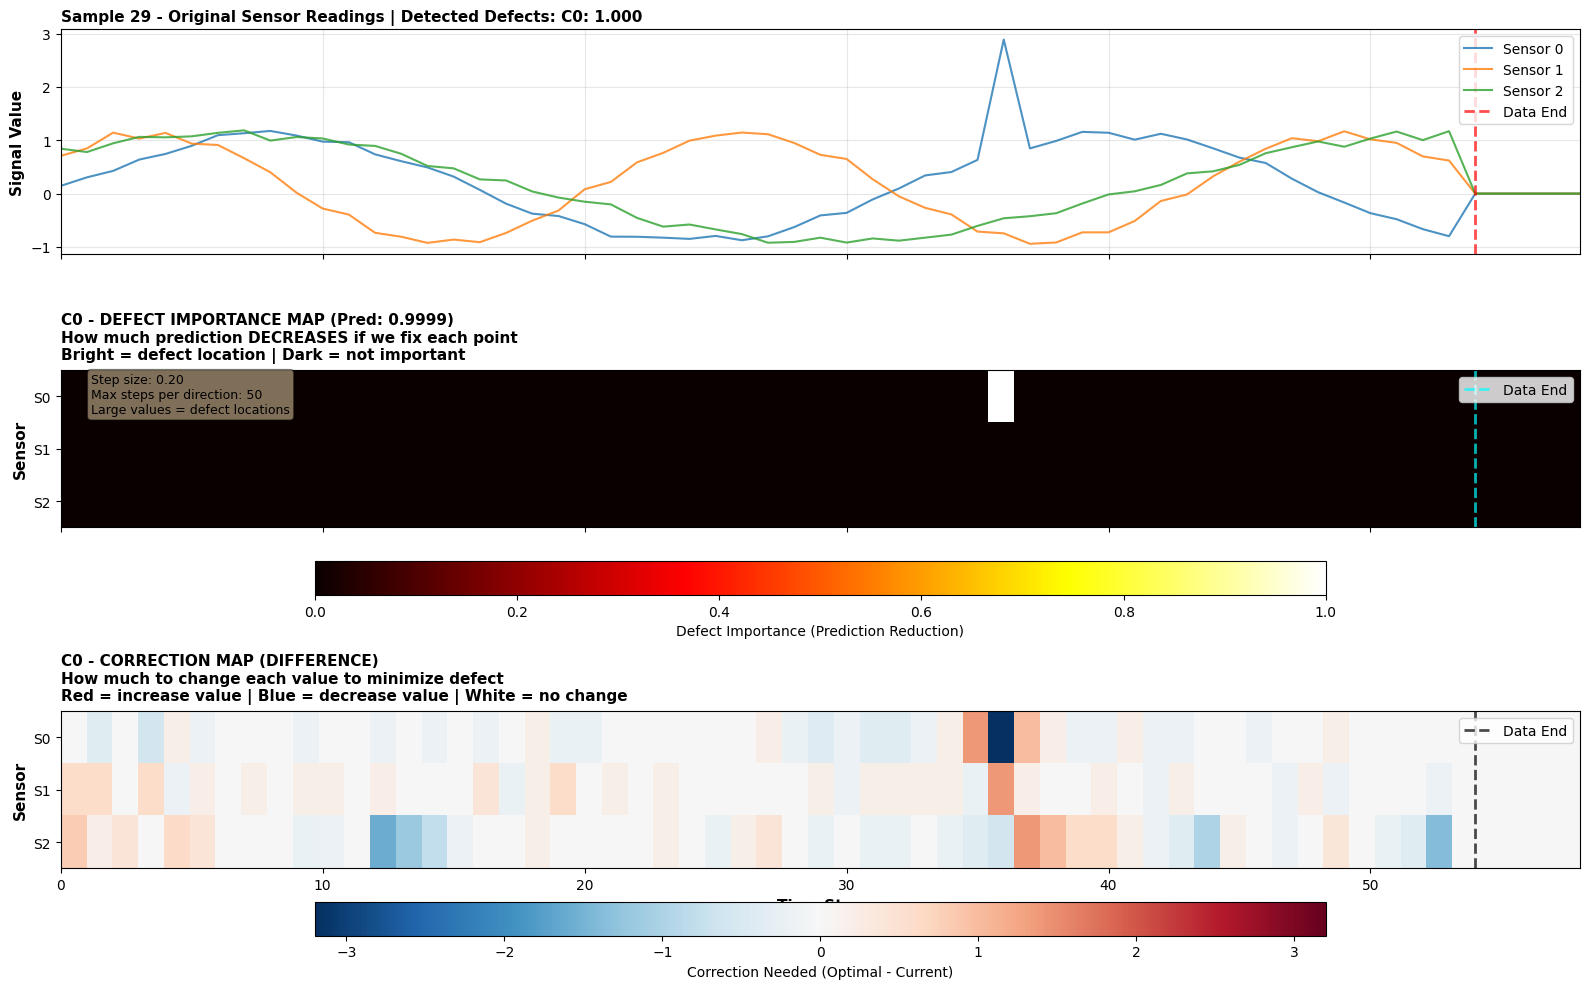

In [20]:
fig, results = visualize_optimal_value_analysis(
    sample_idx=29, 
    X_test=X_test, 
    X_test_scaled=X_test_scaled,
    model=model, 
    max_len=max_len, 
    PADDING_VALUE=PADDING_VALUE,
    classes_to_analyze=[0],
    step_size=0.2,
    max_steps=50
)

Here for multiple points on every sensor we analyze different values that this sensor could take, and how model prediction would change in that case. We find the change in value of that point for which model detection prediction of particular class changes the most. And we see how much that change of value would affect model prediction. 

On example above, on Defect Importance Map we see that model prediction for class 0 would change drastically if we changed value of sensor 0 at point where there is a spike, as this spike is responsible for defect.

Below defect importance map, on correction map we see would be changes in value for each sensor that would most lower model prediction of class 0 defect - we see one point for which it would be best to drastically increase the value, and one point for which it would be best to drastically lower value. But only in one of these cases changing the value would matter much on model prediction (the point where there is a spike)

Detected classes (pred > 0.5): [2]
Running optimal value analysis for 1 class(es): [2]
Step size: 0.2, Max steps: 50
  Global value range: [-1.614, 1.399]


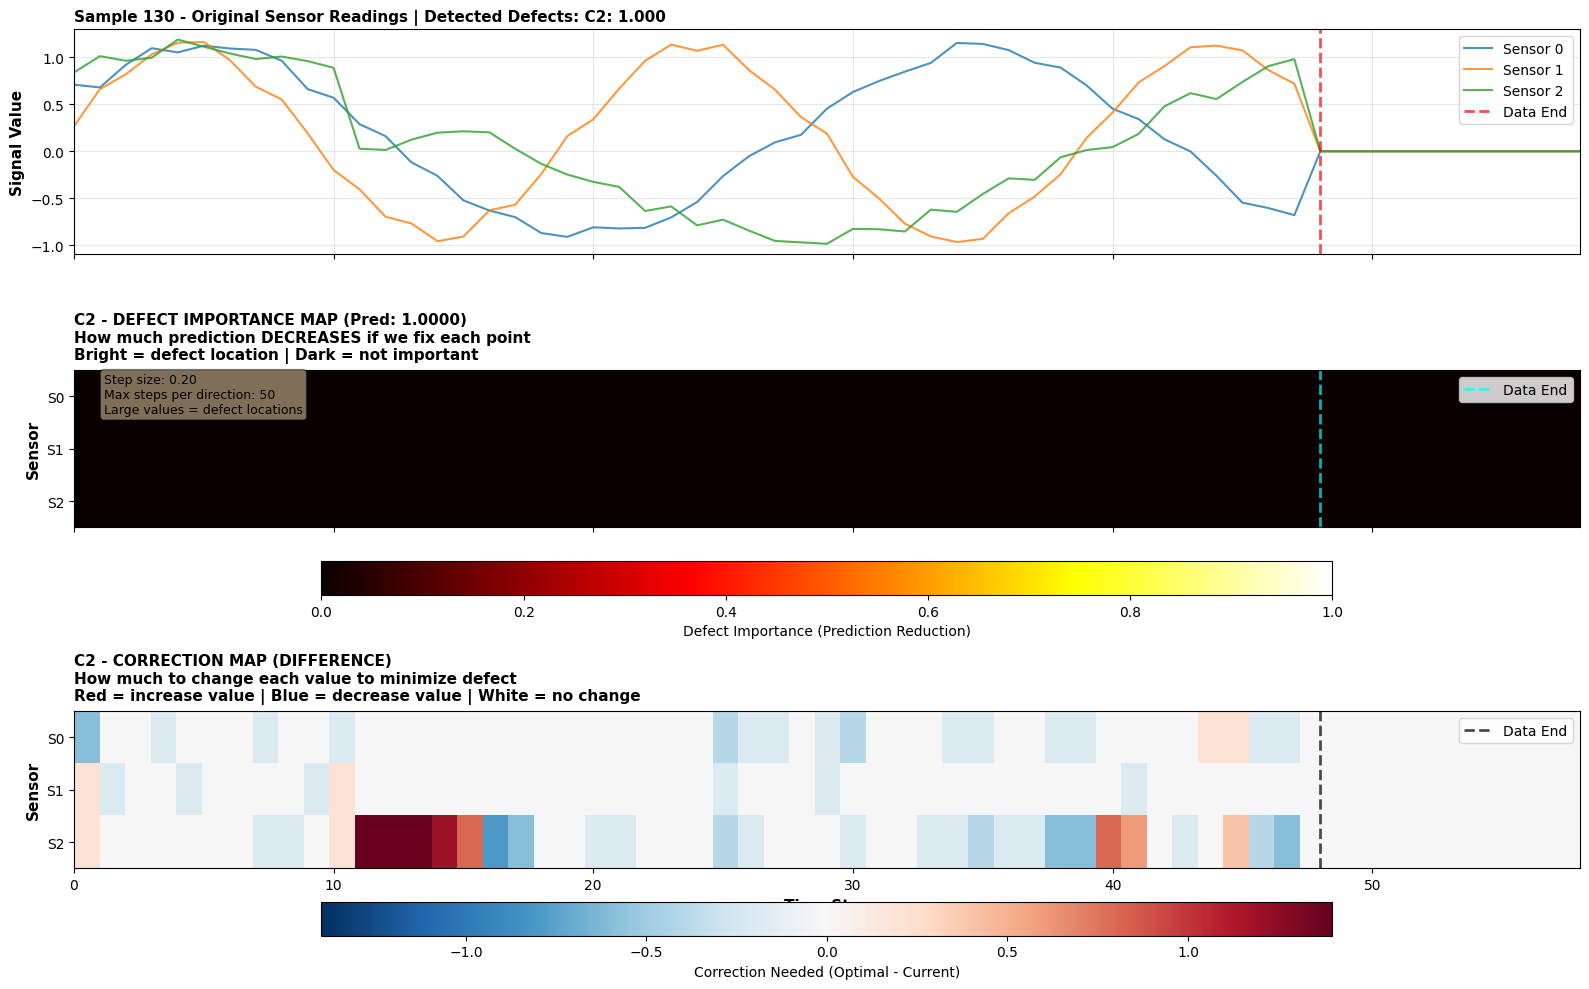

In [21]:
fig, results = visualize_optimal_value_analysis(
    sample_idx=130, 
    X_test=X_test, 
    X_test_scaled=X_test_scaled,
    model=model, 
    max_len=max_len, 
    PADDING_VALUE=PADDING_VALUE,
    classes_to_analyze=None,
    step_size=0.2,
    max_steps=50
)

Here we see that there is no single point, where change in value would change model prediction. That's why class 2 is harder to detect by model. There is no single big spike responsible for defect.